# Long-Term PV Evolution Demo

This notebook demonstrates production-grade long-term PV analysis.

Goal:
- Fit a single-variable linear model between `solar_radiation` and `electricity_produced` on the first 12 months.
- Evaluate subsequent calendar years.
- Report yearly actual vs predicted production and error metrics.
- Include regression diagnostics (coefficient, intercept, R-squared).

In [ ]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from openenergyid.pv_evolution import LongTermPVAnalyzer, PVLongTermAnalysisInput

## 1. Load Typed Input Sample

We use a prebuilt `PVLongTermAnalysisInput` JSON sample:
- path: `data/pv_analysis/pv_long_term_analysis_input.json`
- includes the time series payload (`index`, `columns`, `data`)
- includes metadata (`timeZone`, optional `reference`)

In [ ]:
raw_input = Path("data/pv_analysis/pv_long_term_analysis_input.json").read_text(encoding="utf-8")
analysis_input = PVLongTermAnalysisInput.model_validate_json(raw_input)

In [3]:
input_df = analysis_input.to_pandas(timezone=analysis_input.timezone)
input_df.head()

,electricity_produced,solar_radiation
2021-11-01 00:00:00+01:00,3156.696,23900.10
2021-12-01 00:00:00+01:00,1779.465,13499.88
2022-01-01 00:00:00+01:00,2504.694,19800.01
2022-02-01 00:00:00+01:00,5227.739,41599.88
2022-03-01 00:00:00+01:00,12479.671,103300.06


## 2. Run Long-Term Analysis

The analyzer fits the reference model on the first 12 rows (monthly points) and evaluates each calendar year.

In [4]:
analyzer = LongTermPVAnalyzer()
analysis_output = analyzer.analyze(analysis_input)
analysis_output

PVLongTermAnalysisOutput(reference='sample-pv-site', yearly_results=[PVYearResult(year=2022, actual_production=141568.14, predicted_production=141733.05868881778, error=-164.91868881776463, relative_error=-0.001164942117751668, complete_year=True), PVYearResult(year=2023, actual_production=123519.909, predicted_production=128255.14676632023, error=-4735.237766320235, relative_error=-0.038335826221506004, complete_year=True), PVYearResult(year=2024, actual_production=109272.23599999999, predicted_production=115978.33965876384, error=-6706.103658763852, relative_error=-0.06137060889615046, complete_year=True), PVYearResult(year=2025, actual_production=126849.63600000001, predicted_production=149799.6190601496, error=-22949.983060149578, relative_error=-0.1809227348523852, complete_year=True), PVYearResult(year=2026, actual_production=6101.117, predicted_production=7573.429227934681, error=-1472.3122279346808, relative_error=-0.24131847134462112, complete_year=False)], regression_diagnost

## 3. Inspect Regression Diagnostics

In [5]:
diagnostics_df = pd.DataFrame(
    [
        {
            "coefficient": analysis_output.regression_diagnostics.coefficient,
            "intercept": analysis_output.regression_diagnostics.intercept,
            "r_squared": analysis_output.regression_diagnostics.r_squared,
        }
    ]
)

diagnostics_df

,coefficient,intercept,r_squared
0,0.126434,0.0,0.997447


## 4. Review Per-Year Results

In [6]:
yearly_df = pd.DataFrame(
    [
        {
            "year": row.year,
            "actual_production": row.actual_production,
            "predicted_production": row.predicted_production,
            "error": row.error,
            "relative_error_pct": row.relative_error * 100,
            "complete_year": row.complete_year,
        }
        for row in analysis_output.yearly_results
    ]
)

yearly_df

,year,actual_production,predicted_production,error,relative_error_pct,complete_year
0,2022,141568.140,141733.058689,-164.918689,-0.116494,True
1,2023,123519.909,128255.146766,-4735.237766,-3.833583,True
2,2024,109272.236,115978.339659,-6706.103659,-6.137061,True
3,2025,126849.636,149799.619060,-22949.983060,-18.092273,True
4,2026,6101.117,7573.429228,-1472.312228,-24.131847,False


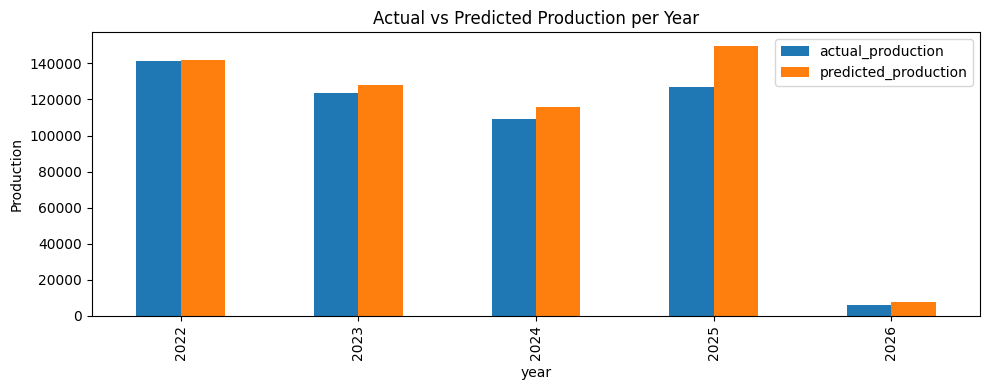

In [7]:
ax = yearly_df.plot(
    x="year",
    y=["actual_production", "predicted_production"],
    kind="bar",
    figsize=(10, 4),
)
ax.set_ylabel("Production")
ax.set_title("Actual vs Predicted Production per Year")
plt.tight_layout()
plt.show()

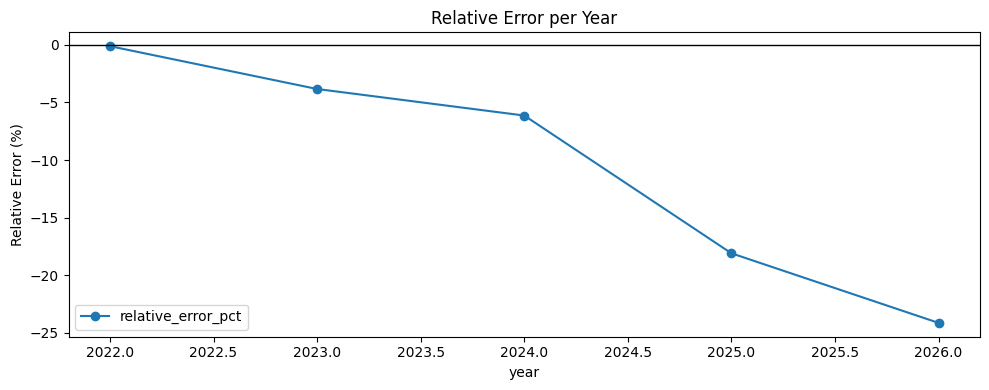

In [8]:
ax = yearly_df.plot(
    x="year",
    y="relative_error_pct",
    marker="o",
    figsize=(10, 4),
)
ax.axhline(0, color="black", linewidth=1)
ax.set_ylabel("Relative Error (%)")
ax.set_title("Relative Error per Year")
plt.tight_layout()
plt.show()

## 5. Serialize Typed Output

`PVLongTermAnalysisOutput` is JSON-ready and supports API aliases.

In [9]:
print(analysis_output.model_dump_json(by_alias=True, indent=2))

{
  "reference": "sample-pv-site",
  "yearlyResults": [
    {
      "year": 2022,
      "actualProduction": 141568.14,
      "predictedProduction": 141733.05868881778,
      "error": -164.91868881776463,
      "relativeError": -0.001164942117751668,
      "completeYear": true
    },
    {
      "year": 2023,
      "actualProduction": 123519.909,
      "predictedProduction": 128255.14676632023,
      "error": -4735.237766320235,
      "relativeError": -0.038335826221506004,
      "completeYear": true
    },
    {
      "year": 2024,
      "actualProduction": 109272.23599999999,
      "predictedProduction": 115978.33965876384,
      "error": -6706.103658763852,
      "relativeError": -0.06137060889615046,
      "completeYear": true
    },
    {
      "year": 2025,
      "actualProduction": 126849.63600000001,
      "predictedProduction": 149799.6190601496,
      "error": -22949.983060149578,
      "relativeError": -0.1809227348523852,
      "completeYear": true
    },
    {
      "year":